# Academic Stress Modeling

## Purpose

This notebook contains the machine-learning workflow for the student stress prototype. The exploratory analysis, statistical inference, and feature-policy rationale remain in `analysis.ipynb`.

The primary experiment estimates Low, Medium, or High stress from contextual circumstances. It is a portfolio prototype—not a diagnosis or a validated future-risk instrument.

## 1. Load the dataset

The path logic supports execution from either the repository root or the `notebooks/` directory. The raw CSV is read without modification.

In [1]:
from pathlib import Path
import hashlib

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "StressLevelDataset.csv"
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

assert df.shape == (1_100, 21)
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0

print(f"File: {DATA_PATH.name}")
print(f"SHA-256: {file_hash}")
print(f"Shape: {df.shape}")

File: StressLevelDataset.csv
SHA-256: 14a45e92708b0c063ad4ab04563aa8fd4e3fc27157fd282e1c0658dc5161faed
Shape: (1100, 21)


## 2. Feature policy

The main student-facing model uses contextual inputs. Mental-health history is optional and self-reported. Proximal symptoms are included only in a comparison experiment, while academic performance remains excluded because its timing is unclear.

In [2]:
main_context_features = [
    "study_load",
    "bullying",
    "social_support",
    "noise_level",
    "peer_pressure",
    "teacher_student_relationship",
    "living_conditions",
    "safety",
    "basic_needs",
    "extracurricular_activities",
]

optional_sensitive_features = ["mental_health_history"]

proximal_comparison_features = [
    "anxiety_level",
    "self_esteem",
    "depression",
    "headache",
    "blood_pressure",
    "sleep_quality",
    "breathing_problem",
    "future_career_concerns",
]

excluded_features = {
    "academic_performance": (
        "Timing is unclear and performance may be a consequence of stress."
    ),
}

target_column = "stress_level"
context_with_history_features = main_context_features + optional_sensitive_features
full_comparison_features = (
    main_context_features
    + optional_sensitive_features
    + proximal_comparison_features
)

policy_groups = [
    set(main_context_features),
    set(optional_sensitive_features),
    set(proximal_comparison_features),
    set(excluded_features),
]
assert all(group <= set(df.columns) for group in policy_groups)
assert not any(
    left & right
    for index, left in enumerate(policy_groups)
    for right in policy_groups[index + 1:]
)
assert target_column not in set().union(*policy_groups)

feature_policy_table = pd.DataFrame({
    "role": [
        "Main context model",
        "Optional sensitive input",
        "Proximal comparison only",
        "Excluded",
    ],
    "variables": [
        ", ".join(main_context_features),
        ", ".join(optional_sensitive_features),
        ", ".join(proximal_comparison_features),
        ", ".join(excluded_features),
    ],
})

feature_policy_table

,role,variables
0,Main context model,"study_load, bullying, social_support, noise_le..."
1,Optional sensitive input,mental_health_history
2,Proximal comparison only,"anxiety_level, self_esteem, depression, headac..."
3,Excluded,academic_performance


## 3. Evaluation design

The model-development workflow uses a stratified 80/20 split:

- **Training set:** preprocessing, five-fold cross-validation, and model selection
- **Test set:** one final evaluation after model selection

The primary metric is **High-stress recall**, because missing a student who is actually in the High-stress class is the most important error. Precision and class-balanced metrics remain necessary to detect excessive false alerts.

In [3]:
from sklearn.model_selection import StratifiedKFold, train_test_split

TEST_SIZE = 0.20
SPLIT_RANDOM_STATE = 20_260_827
CV_FOLDS = 5

stress_labels = {0: "Low", 1: "Medium", 2: "High"}
y = df[target_column].copy()
all_indices = df.index.to_numpy()

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

assert len(train_indices) == 880
assert len(test_indices) == 220
assert not set(train_indices) & set(test_indices)
assert set(train_indices) | set(test_indices) == set(all_indices)

y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

experiment_features = {
    "context_only": main_context_features,
    "context_with_history": context_with_history_features,
    "full_comparison": full_comparison_features,
}

experiment_splits = {}
for experiment_name, feature_names in experiment_features.items():
    experiment_splits[experiment_name] = {
        "X_train": df.loc[train_indices, feature_names].copy(),
        "X_test": df.loc[test_indices, feature_names].copy(),
    }

X_train = experiment_splits["context_only"]["X_train"]
X_test = experiment_splits["context_only"]["X_test"]

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=SPLIT_RANDOM_STATE,
)

split_rows = []
for split_name, split_target in [("Training", y_train), ("Test", y_test)]:
    counts = split_target.value_counts().sort_index()
    for code_value, label in stress_labels.items():
        count = int(counts.get(code_value, 0))
        split_rows.append({
            "split": split_name,
            "stress_level": label,
            "count": count,
            "percent": round(count / len(split_target) * 100, 1),
        })

split_balance_table = pd.DataFrame(split_rows)
split_balance_table

,split,stress_level,count,percent
0,Training,Low,299,34.0
1,Training,Medium,286,32.5
2,Training,High,295,33.5
3,Test,Low,74,33.6
4,Test,Medium,72,32.7
5,Test,High,74,33.6


## 4. Leakage-safe preprocessing

Imputation and scaling are enclosed inside each model pipeline. During cross-validation, the transformations therefore learn parameters only from the current training fold—not from validation or test students.

In [4]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def make_preprocessor(feature_names):
    """Build preprocessing that learns parameters from training data only."""
    numeric_steps = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("scale", StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[("coded", numeric_steps, feature_names)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator, feature_names):
    """Combine preprocessing and a model to prevent preprocessing leakage."""
    return Pipeline([
        ("preprocess", make_preprocessor(feature_names)),
        ("model", clone(estimator)),
    ])


preprocessing_validation = make_preprocessor(main_context_features)
X_train_prepared = preprocessing_validation.fit_transform(X_train)
X_test_prepared = preprocessing_validation.transform(X_test)

assert X_train_prepared.shape == (880, len(main_context_features))
assert X_test_prepared.shape == (220, len(main_context_features))
assert np.isfinite(X_train_prepared).all()
assert np.isfinite(X_test_prepared).all()

preprocessing_check = pd.DataFrame({
    "check": [
        "Training rows",
        "Test rows",
        "Main context features",
        "Training/test index overlap",
        "Missing values in main experiment",
        "Target included among predictors",
    ],
    "result": [
        len(X_train),
        len(X_test),
        X_train.shape[1],
        len(set(train_indices) & set(test_indices)),
        int(X_train.isna().sum().sum() + X_test.isna().sum().sum()),
        target_column in X_train.columns,
    ],
})

preprocessing_check

,check,result
0,Training rows,880
1,Test rows,220
2,Main context features,10
3,Training/test index overlap,0
4,Missing values in main experiment,0
5,Target included among predictors,False


In [5]:
from sklearn.metrics import f1_score, make_scorer, recall_score

HIGH_STRESS_LABEL = 2

SCORING = {
    "high_stress_recall": make_scorer(
        recall_score,
        labels=[HIGH_STRESS_LABEL],
        average="macro",
        zero_division=0,
    ),
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "balanced_accuracy": "balanced_accuracy",
}

evaluation_policy = pd.DataFrame({
    "role": ["Primary", "Supporting", "Supporting", "Diagnostic"],
    "metric": [
        "High-stress recall",
        "High-stress precision",
        "Macro F1 and balanced accuracy",
        "Confusion matrix and per-class metrics",
    ],
    "purpose": [
        "Prioritize finding students who are actually High stress",
        "Monitor false High-stress alerts",
        "Check performance across all three classes",
        "Show which classes are confused",
    ],
})

evaluation_policy

,role,metric,purpose
0,Primary,High-stress recall,Prioritize finding students who are actually H...
1,Supporting,High-stress precision,Monitor false High-stress alerts
2,Supporting,Macro F1 and balanced accuracy,Check performance across all three classes
3,Diagnostic,Confusion matrix and per-class metrics,Show which classes are confused


## 5. Preparation result

- The training set contains 880 students and the untouched test set contains 220.
- Class proportions are nearly identical across the two sets.
- All feature experiments reuse the same student indices for fair comparisons.
- Preprocessing is fitted only within the relevant training data.
- High-stress recall is primary, but it will never be interpreted without precision and class-balanced metrics.

The integer feature codes are treated as ordered numeric measurements. Because several code definitions remain only partially documented, this is an explicit limitation.


## 6. Baseline models

Three context-only baselines are compared using the same five stratified training folds. Every estimator is enclosed in the preprocessing pipeline, so imputation and scaling are refitted inside each fold.

- The Dummy classifier establishes the minimum benchmark.
- Logistic regression provides an interpretable linear baseline.
- A depth-three decision tree provides a small nonlinear baseline.

The held-out test set is not used in this comparison.

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier

high_stress_precision_scorer = make_scorer(
    precision_score,
    labels=[HIGH_STRESS_LABEL],
    average="macro",
    zero_division=0,
)

baseline_scoring = {
    **SCORING,
    "high_stress_precision": high_stress_precision_scorer,
    "accuracy": "accuracy",
}

baseline_models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(
        max_iter=2_000,
        random_state=SPLIT_RANDOM_STATE,
    ),
    "Decision tree (depth 3)": DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=20,
        random_state=SPLIT_RANDOM_STATE,
    ),
}

result_rows = []
fold_rows = []

for model_name, estimator in baseline_models.items():
    pipeline = make_model_pipeline(estimator, main_context_features)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=baseline_scoring,
        return_train_score=True,
    )

    for metric_name in baseline_scoring:
        validation_scores = scores[f"test_{metric_name}"]
        training_scores = scores[f"train_{metric_name}"]
        result_rows.append({
            "model": model_name,
            "metric": metric_name,
            "cv_mean": validation_scores.mean(),
            "cv_sd": validation_scores.std(ddof=1),
            "train_mean": training_scores.mean(),
            "train_cv_gap": training_scores.mean() - validation_scores.mean(),
        })

        for fold_number, score in enumerate(validation_scores, start=1):
            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "metric": metric_name,
                "score": score,
            })

baseline_results = pd.DataFrame(result_rows)
baseline_fold_results = pd.DataFrame(fold_rows)

metric_labels = {
    "high_stress_recall": "High recall",
    "high_stress_precision": "High precision",
    "macro_f1": "Macro F1",
    "balanced_accuracy": "Balanced accuracy",
    "accuracy": "Accuracy",
}
model_order = list(baseline_models)

performance_values = (
    baseline_results
    .pivot(index="model", columns="metric", values="cv_mean")
    .reindex(model_order)
    .rename(columns=metric_labels)
)
recall_sd = (
    baseline_results
    .query("metric == 'high_stress_recall'")
    .set_index("model")["cv_sd"]
    .reindex(model_order)
    .rename("Recall SD")
)

baseline_summary = (
    performance_values[
        [
            "High recall",
            "High precision",
            "Macro F1",
            "Balanced accuracy",
            "Accuracy",
        ]
    ]
    .join(recall_sd)
    .reset_index()
    .rename(columns={"model": "Model"})
)

baseline_summary.round(3)

,Model,High recall,High precision,Macro F1,Balanced accuracy,Accuracy,Recall SD
0,Dummy (most frequent),0.000,0.000,0.169,0.333,0.340,0.000
1,Logistic regression,0.875,0.847,0.868,0.868,0.868,0.068
2,Decision tree (depth 3),0.841,0.920,0.872,0.872,0.872,0.065


In [7]:
recall_folds = (
    baseline_fold_results
    .query("metric == 'high_stress_recall'")
    .pivot(index="model", columns="fold", values="score")
    .reindex(model_order)
)

recall_stability = pd.DataFrame({
    "Model": model_order,
    "Minimum fold recall": recall_folds.min(axis=1).to_numpy(),
    "Maximum fold recall": recall_folds.max(axis=1).to_numpy(),
    "Recall range": (
        recall_folds.max(axis=1) - recall_folds.min(axis=1)
    ).to_numpy(),
})

recall_stability.round(3)

,Model,Minimum fold recall,Maximum fold recall,Recall range
0,Dummy (most frequent),0.000,0.000,0.000
1,Logistic regression,0.780,0.949,0.169
2,Decision tree (depth 3),0.763,0.932,0.169


### Baseline findings

- The most-frequent Dummy classifier predicts Low stress for every student and has zero High-stress recall.
- Logistic regression has the highest mean High-stress recall (`0.875`) and is the **provisional baseline leader** for the application objective.
- The decision tree has lower High-stress recall (`0.841`) but higher High-stress precision (`0.920`).
- Logistic regression and the decision tree have similar fold-to-fold recall variability (`SD = 0.068` and `0.065`). The small mean-recall difference does not establish a stable final ranking.
- No model is selected as final, and the test set remains untouched.

## 7. Repeated model comparison

Five fixed context-only candidates are compared using five stratified folds repeated ten times. This produces 50 validation scores per model and reduces dependence on one particular fold assignment.

The evaluation adds two prevention-focused measures:

- **Elevated-stress recall:** among actual Medium- or High-stress students, the proportion predicted as at least Medium.
- **High-to-Low error:** among actual High-stress students, the proportion incorrectly predicted as Low. Lower is better.

The High class receives 1.5 times the standard weight in the weighted logistic candidate. The held-out test set remains untouched.

In [8]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC


def prevention_metrics(y_true, y_pred):
    """Return class-specific and prevention-focused evaluation metrics."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    high_mask = y_true == HIGH_STRESS_LABEL

    return {
        "high_recall": recall_score(
            y_true,
            y_pred,
            labels=[HIGH_STRESS_LABEL],
            average="macro",
            zero_division=0,
        ),
        "high_precision": precision_score(
            y_true,
            y_pred,
            labels=[HIGH_STRESS_LABEL],
            average="macro",
            zero_division=0,
        ),
        "elevated_recall": recall_score(
            y_true >= 1,
            y_pred >= 1,
            pos_label=True,
            zero_division=0,
        ),
        "high_to_low_rate": (
            float(np.mean(y_pred[high_mask] == 0))
            if high_mask.any()
            else np.nan
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


REPEATED_CV_RANDOM_STATE = 20_260_828
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=REPEATED_CV_RANDOM_STATE,
)

comparison_models = {
    "Logistic": LogisticRegression(
        max_iter=2_000,
        random_state=SPLIT_RANDOM_STATE,
    ),
    "Weighted logistic": LogisticRegression(
        max_iter=2_000,
        class_weight={0: 1.0, 1: 1.0, 2: 1.5},
        random_state=SPLIT_RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=SPLIT_RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=10,
        random_state=SPLIT_RANDOM_STATE,
    ),
    "RBF SVC": SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        random_state=SPLIT_RANDOM_STATE,
    ),
}

comparison_rows = []
for model_name, estimator in comparison_models.items():
    for fold_number, (fit_positions, validation_positions) in enumerate(
        repeated_cv.split(X_train, y_train),
        start=1,
    ):
        pipeline = make_model_pipeline(estimator, main_context_features)
        X_fit = X_train.iloc[fit_positions]
        y_fit = y_train.iloc[fit_positions]
        X_validation = X_train.iloc[validation_positions]
        y_validation = y_train.iloc[validation_positions]

        pipeline.fit(X_fit, y_fit)
        predictions = pipeline.predict(X_validation)
        comparison_rows.append({
            "model": model_name,
            "fold": fold_number,
            **prevention_metrics(y_validation, predictions),
        })

repeated_cv_results = pd.DataFrame(comparison_rows)
model_order = list(comparison_models)

comparison_summary = (
    repeated_cv_results
    .groupby("model")
    .agg(
        high_recall=("high_recall", "mean"),
        recall_sd=("high_recall", "std"),
        high_precision=("high_precision", "mean"),
        elevated_recall=("elevated_recall", "mean"),
        high_to_low_error=("high_to_low_rate", "mean"),
        macro_f1=("macro_f1", "mean"),
        balanced_accuracy=("balanced_accuracy", "mean"),
    )
    .reindex(model_order)
    .reset_index()
    .rename(columns={
        "model": "Model",
        "high_recall": "High recall",
        "recall_sd": "Recall SD",
        "high_precision": "High precision",
        "elevated_recall": "Elevated recall",
        "high_to_low_error": "High-to-Low error",
        "macro_f1": "Macro F1",
        "balanced_accuracy": "Balanced accuracy",
    })
)

comparison_summary.round(3)

,Model,High recall,Recall SD,High precision,Elevated recall,High-to-Low error,Macro F1,Balanced accuracy
0,Logistic,0.888,0.039,0.851,0.948,0.065,0.873,0.874
1,Weighted logistic,0.905,0.039,0.825,0.954,0.057,0.871,0.871
2,Random forest,0.876,0.047,0.876,0.926,0.073,0.878,0.878
3,Gradient boosting,0.882,0.038,0.859,0.945,0.062,0.881,0.881
4,RBF SVC,0.880,0.041,0.881,0.927,0.074,0.876,0.876


In [ ]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

recall_distributions = [
    repeated_cv_results.loc[
        repeated_cv_results["model"].eq(model_name),
        "high_recall",
    ].to_numpy()
    for model_name in model_order
]

stability_fig, ax = plt.subplots(figsize=(10, 5.8))
boxplot = ax.boxplot(
    recall_distributions,
    tick_labels=model_order,
    orientation="horizontal",
    patch_artist=True,
    showfliers=True,
    medianprops={"color": "#1F2937", "linewidth": 1.6},
    whiskerprops={"color": "#64748B"},
    capprops={"color": "#64748B"},
    flierprops={
        "marker": "o",
        "markersize": 3,
        "markerfacecolor": "#94A3B8",
        "markeredgecolor": "none",
        "alpha": 0.7,
    },
)

for patch, color in zip(
    boxplot["boxes"],
    ["#93C5FD", "#2563EB", "#A7F3D0", "#FCD34D", "#C4B5FD"],
):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

mean_recall = repeated_cv_results.groupby("model")["high_recall"].mean()
for position, model_name in enumerate(model_order, start=1):
    ax.scatter(
        mean_recall.loc[model_name],
        position,
        marker="D",
        color="#111827",
        s=28,
        zorder=3,
        label="Mean" if position == 1 else None,
    )

ax.set_xlim(0.70, 1.01)
ax.set_xlabel("High-stress recall across validation folds")
ax.set_title(
    "High-Stress Recall Stability Across 50 Validation Folds",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="x", alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
stability_fig.text(
    0.5,
    0.01,
    "Five folds repeated ten times on the training set; the held-out test set is not used.",
    ha="center",
    fontsize=9,
)
stability_fig.tight_layout(rect=[0, 0.04, 1, 1])

stability_output = FIGURES_DIR / "repeated-cv-high-recall-stability.png"
stability_fig.savefig(stability_output, dpi=300, bbox_inches="tight")
plt.show()

### Phase 6 decision

- Weighted logistic regression has the highest mean High-stress recall (`0.905`) and Elevated-stress recall (`0.954`).
- It also has the lowest High-to-Low error rate (`0.057`).
- Weighting reduces High-stress precision from `0.851` to `0.825`; this additional false-alert cost was accepted because missed elevated-stress students are the higher-priority error.
- Gradient boosting remains the balanced comparison model because it has the strongest Macro F1 and balanced accuracy (`0.881`).
- Weighted logistic regression is the **provisional selected model** for one-time test evaluation. This is an internal model-selection result and does not establish real-world validity.

## 8. Held-out test evaluation

The selected weighted-logistic pipeline is fitted once on all 880 training students and evaluated once on the 220 students reserved in Phase 4. The model configuration and feature policy are frozen before this evaluation.

These test results estimate performance on unseen records from this dataset. They must not be used to retune the model, and they do not establish performance for students from a different population.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
)

selected_estimator = LogisticRegression(
    max_iter=2_000,
    class_weight={0: 1.0, 1: 1.0, 2: 1.5},
    random_state=SPLIT_RANDOM_STATE,
)
selected_pipeline = make_model_pipeline(
    selected_estimator,
    main_context_features,
)
selected_pipeline.fit(X_train, y_train)

test_predictions = selected_pipeline.predict(X_test)
test_probabilities = selected_pipeline.predict_proba(X_test)

# Test metrics are calculated once after the model configuration is frozen.
test_metric_values = prevention_metrics(y_test, test_predictions)
test_metric_values.update({
    "accuracy": accuracy_score(y_test, test_predictions),
    "multiclass_log_loss": log_loss(
        y_test,
        test_probabilities,
        labels=[0, 1, 2],
    ),
})

metric_labels = {
    "high_recall": "High-stress recall",
    "high_precision": "High-stress precision",
    "elevated_recall": "Elevated-stress recall",
    "high_to_low_rate": "High-to-Low error",
    "macro_f1": "Macro F1",
    "balanced_accuracy": "Balanced accuracy",
    "accuracy": "Accuracy",
    "multiclass_log_loss": "Multiclass log loss",
}

test_metrics_table = pd.DataFrame({
    "Metric": [metric_labels[key] for key in test_metric_values],
    "Test value": list(test_metric_values.values()),
})

test_metrics_table.round(3)

Metric,Test value
High-stress recall,0.851
High-stress precision,0.840
Elevated-stress recall,0.938
High-to-Low error,0.081
Macro F1,0.873
Balanced accuracy,0.873
Accuracy,0.873
Multiclass log loss,0.413


In [ ]:
class_names = ["Low", "Medium", "High"]
class_report = (
    pd.DataFrame(
        classification_report(
            y_test,
            test_predictions,
            labels=[0, 1, 2],
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    )
    .T
    .loc[class_names, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={
        "index": "Class",
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1",
        "support": "Support",
    })
)

class_report.round(3)

Class,Precision,Recall,F1,Support
Low,0.877,0.865,0.871,74
Medium,0.903,0.903,0.903,72
High,0.840,0.851,0.846,74


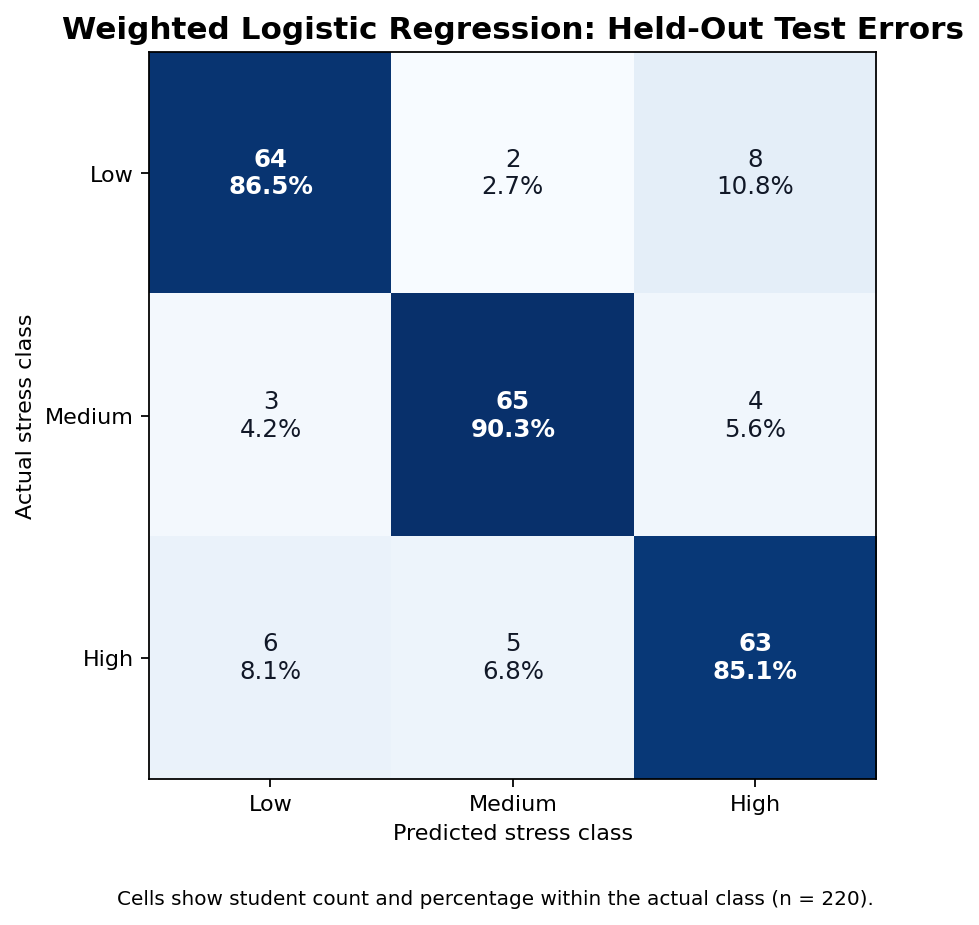

In [ ]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

test_confusion = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1, 2],
)

confusion_fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.imshow(test_confusion, cmap="Blues")
row_totals = test_confusion.sum(axis=1, keepdims=True)

for row_index in range(test_confusion.shape[0]):
    for column_index in range(test_confusion.shape[1]):
        count = int(test_confusion[row_index, column_index])
        percentage = count / row_totals[row_index, 0]
        text_color = (
            "white"
            if count > test_confusion.max() / 2
            else "#111827"
        )
        ax.text(
            column_index,
            row_index,
            f"{count}\n{percentage:.1%}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight=(
                "bold" if row_index == column_index else "normal"
            ),
        )

ax.set_xticks(range(3), class_names)
ax.set_yticks(range(3), class_names)
ax.set_xlabel("Predicted stress class")
ax.set_ylabel("Actual stress class")
ax.set_title(
    "Weighted Logistic Regression: Held-Out Test Errors",
    fontsize=14,
    fontweight="bold",
)
confusion_fig.text(
    0.5,
    0.015,
    "Cells show student count and percentage within the actual class (n = 220).",
    ha="center",
    fontsize=9,
)
confusion_fig.tight_layout(rect=[0, 0.05, 1, 1])

confusion_output = FIGURES_DIR / "final-test-confusion-matrix.png"
confusion_fig.savefig(confusion_output, dpi=300, bbox_inches="tight")
plt.show()

### Test-error findings

- The model correctly identifies 63 of 74 High-stress students (`recall = 0.851`).
- Eleven High-stress students are missed: five are predicted Medium and six are predicted Low.
- The six High-to-Low errors are the most consequential underclassifications (`8.1%` of actual High-stress students).
- Elevated-stress recall is `0.938`: 137 of 146 actual Medium- or High-stress students are predicted as at least Medium.
- Test High-stress recall is below the repeated-CV mean (`0.905`) and near the lower end of its validation distribution. This generalization gap is reported without modifying the model.

## 9. Model interpretation

The coefficients below describe how each standardized contextual input contributes to the model's High-stress score while the other inputs are held fixed. Positive values increase the High-class score; negative values decrease it.

Because the predictors are correlated, a multivariable coefficient can differ from a feature's simple correlation. Coefficients are model associations—not causal effects or individual explanations.

In [ ]:
feature_names = (
    selected_pipeline
    .named_steps["preprocess"]
    .get_feature_names_out()
)
model_classes = selected_pipeline.named_steps["model"].classes_
high_class_position = int(
    np.where(model_classes == HIGH_STRESS_LABEL)[0][0]
)

high_class_coefficients = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": selected_pipeline.named_steps["model"].coef_[
            high_class_position
        ],
    })
    .sort_values("Coefficient")
    .reset_index(drop=True)
)

high_class_coefficients.assign(
    Feature=lambda table: (
        table["Feature"].str.replace("_", " ").str.title()
    )
).round(3)

Feature,Coefficient
Social Support,-1.018
Safety,-0.292
Basic Needs,-0.252
Living Conditions,-0.116
Teacher Student Relationship,0.185
Peer Pressure,0.339
Noise Level,0.446
Bullying,0.465
Study Load,0.480
Extracurricular Activities,0.572


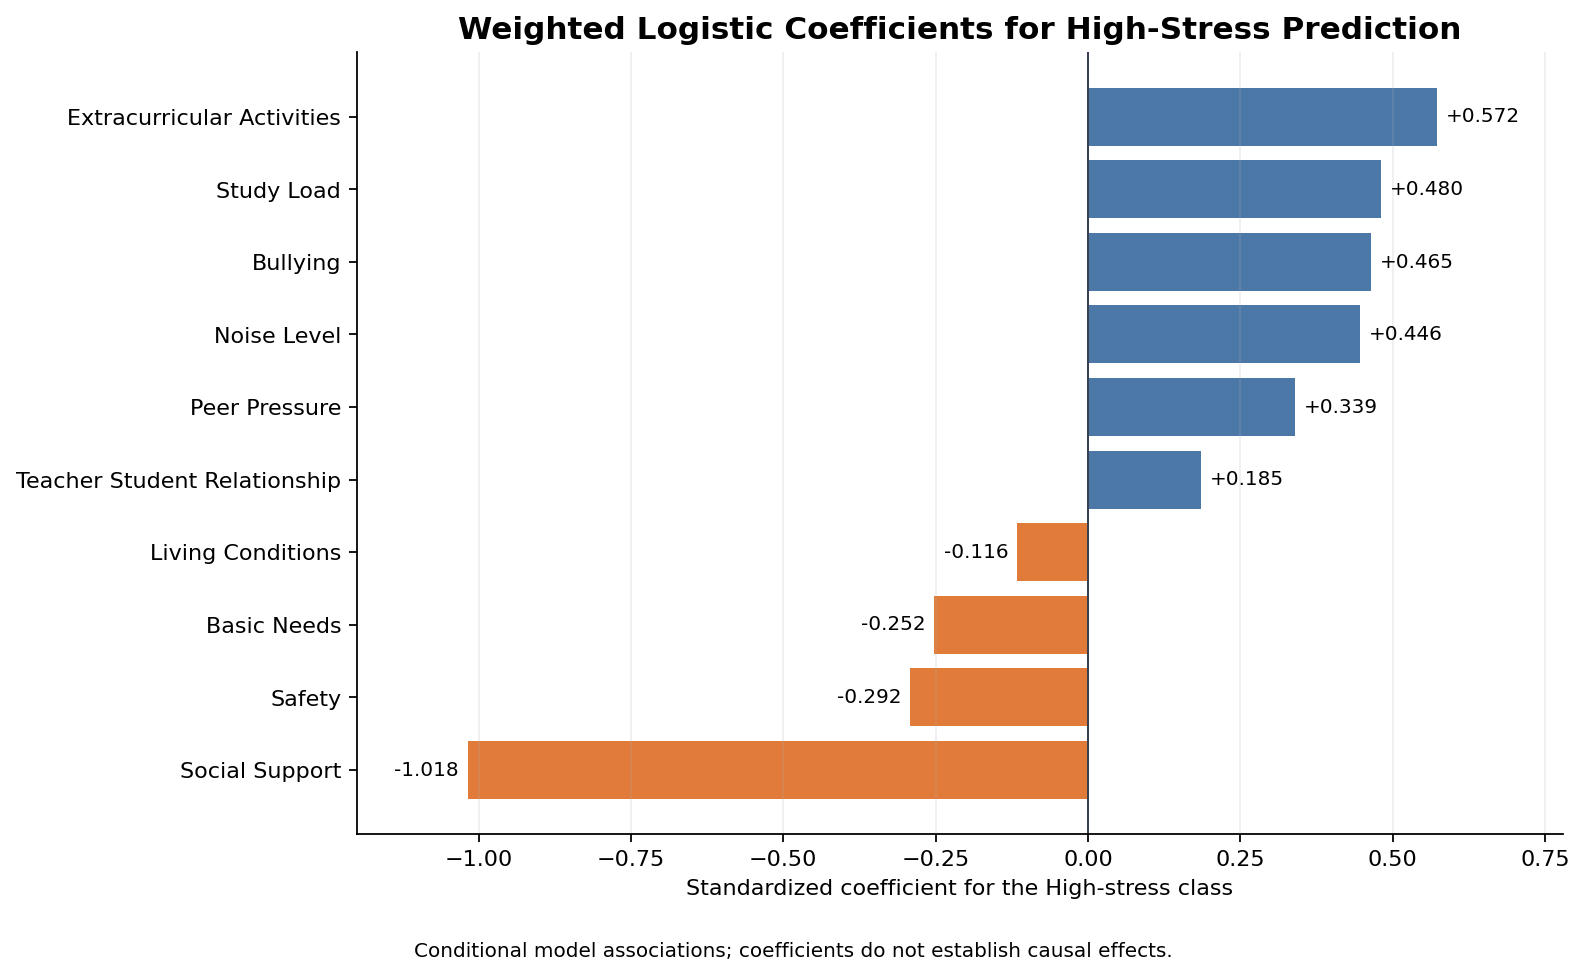

In [ ]:
coefficient_labels = (
    high_class_coefficients["Feature"]
    .str.replace("_", " ")
    .str.title()
)
coefficient_colors = [
    "#4C78A8" if value > 0 else "#E07B39"
    for value in high_class_coefficients["Coefficient"]
]

coefficient_fig, ax = plt.subplots(figsize=(10, 6.1))
bars = ax.barh(
    coefficient_labels,
    high_class_coefficients["Coefficient"],
    color=coefficient_colors,
)
ax.axvline(0, color="#374151", linewidth=0.9)
ax.bar_label(
    bars,
    labels=[
        f"{value:+.3f}"
        for value in high_class_coefficients["Coefficient"]
    ],
    padding=4,
    fontsize=9,
)
ax.set_xlim(-1.20, 0.78)
ax.set_xlabel("Standardized coefficient for the High-stress class")
ax.set_title(
    "Weighted Logistic Coefficients for High-Stress Prediction",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="x", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
coefficient_fig.text(
    0.5,
    0.01,
    "Conditional model associations; coefficients do not establish causal effects.",
    ha="center",
    fontsize=9,
)
coefficient_fig.tight_layout(rect=[0, 0.04, 1, 1])

coefficient_output = (
    FIGURES_DIR / "weighted-logistic-high-class-coefficients.png"
)
coefficient_fig.savefig(coefficient_output, dpi=300, bbox_inches="tight")
plt.show()

### Interpretation findings

- Lower social-support codes contribute most strongly toward the model's High-stress score (`coefficient = −1.018`, assuming higher codes indicate greater support).
- Higher extracurricular-activity, study-load, bullying, noise, and peer-pressure codes contribute positively to the High-stress score.
- The positive teacher–student-relationship coefficient differs from its negative univariate correlation, illustrating why correlated multivariable coefficients must be interpreted cautiously.
- The coefficient magnitudes depend on the dataset's coding, scaling, feature set, and model. They should not be used as causal intervention priorities.

## 10. Current modeling results

- Weighted logistic regression was selected using repeated cross-validation on the training data.
- Its one-time held-out test results are: High-stress recall `0.851`, High-stress precision `0.840`, Elevated-stress recall `0.938`, Macro F1 `0.873`, and balanced accuracy `0.873`.
- Six of 74 actual High-stress students are severely underclassified as Low.
- Coefficients provide conditional model interpretation but no causal evidence.
- The test set is now considered used and will not guide further tuning.

**Next phase:** package the selected preprocessing and weighted logistic-regression model for reuse in the application. A separate robustness phase is intentionally omitted to keep the project focused; responsible-use boundaries will be documented in the application and README.

## 11. Final model pipeline

The selected preprocessing and weighted logistic-regression estimator are saved together so the application cannot accidentally bypass imputation or scaling.

The held-out results above remain the evaluation evidence. After recording them, the selected pipeline is cloned and refit on all 1,100 rows for the portfolio application. This final all-data artifact has no separate unbiased test estimate.

In [ ]:
input_schema = {
    feature: {
        "type": "integer",
        "allowed_values": [
            int(value)
            for value in sorted(df[feature].dropna().unique())
        ],
    }
    for feature in main_context_features
}

input_schema_table = pd.DataFrame({
    "Feature": main_context_features,
    "Required": True,
    "Type": "Integer code",
    "Allowed values": [
        ", ".join(map(str, input_schema[feature]["allowed_values"]))
        for feature in main_context_features
    ],
})

input_schema_table

,Feature,Required,Type,Allowed values
0,study_load,True,Integer code,"0, 1, 2, 3, 4, 5"
1,bullying,True,Integer code,"0, 1, 2, 3, 4, 5"
2,social_support,True,Integer code,"0, 1, 2, 3"
3,noise_level,True,Integer code,"0, 1, 2, 3, 4, 5"
4,peer_pressure,True,Integer code,"0, 1, 2, 3, 4, 5"
5,teacher_student_relationship,True,Integer code,"0, 1, 2, 3, 4, 5"
6,living_conditions,True,Integer code,"0, 1, 2, 3, 4, 5"
7,safety,True,Integer code,"0, 1, 2, 3, 4, 5"
8,basic_needs,True,Integer code,"0, 1, 2, 3, 4, 5"
9,extracurricular_activities,True,Integer code,"0, 1, 2, 3, 4, 5"


In [ ]:
import hashlib
import json
import platform

import joblib
import sklearn
from sklearn.base import clone

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "stress_risk_pipeline.joblib"
METADATA_PATH = MODELS_DIR / "stress_risk_model_metadata.json"

# Refit only after model selection and held-out evaluation are complete.
final_pipeline = clone(selected_pipeline)
final_pipeline.fit(df[main_context_features], y)
joblib.dump(final_pipeline, MODEL_PATH, compress=3)
model_hash = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()

model_metadata = {
    "artifact_version": "1.0.0",
    "model_file": MODEL_PATH.name,
    "model_sha256": model_hash,
    "model_type": "Weighted multinomial logistic regression",
    "pipeline_steps": [
        "most-frequent imputation",
        "standard scaling",
        "classification",
    ],
    "features_in_order": main_context_features,
    "input_schema": input_schema,
    "target": target_column,
    "class_labels": {str(key): value for key, value in stress_labels.items()},
    "class_weights": {"0": 1.0, "1": 1.0, "2": 1.5},
    "training_rows": int(len(df)),
    "training_dataset_sha256": file_hash,
    "random_state": SPLIT_RANDOM_STATE,
    "python_version": platform.python_version(),
    "scikit_learn_version": sklearn.__version__,
    "joblib_version": joblib.__version__,
    "held_out_evaluation": {
        "note": "Metrics were measured before the final all-data refit.",
        "high_stress_recall": 0.851351,
        "high_stress_precision": 0.840000,
        "elevated_stress_recall": 0.938356,
        "macro_f1": 0.873086,
        "balanced_accuracy": 0.872998,
    },
    "use_boundaries": [
        "Portfolio prototype; not a diagnostic or clinical instrument.",
        "Do not use for automatic academic or disciplinary decisions.",
        "Dataset code meanings and external validity are not independently verified.",
        "Load the joblib file only from a trusted source.",
    ],
}
METADATA_PATH.write_text(
    json.dumps(model_metadata, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

artifact_summary = pd.DataFrame([
    {
        "Artifact": "Pipeline",
        "Repository path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
        "Size (KB)": round(MODEL_PATH.stat().st_size / 1024, 1),
        "SHA-256": model_hash,
    },
    {
        "Artifact": "Metadata and input schema",
        "Repository path": str(METADATA_PATH.relative_to(PROJECT_ROOT)),
        "Size (KB)": round(METADATA_PATH.stat().st_size / 1024, 1),
        "SHA-256": hashlib.sha256(METADATA_PATH.read_bytes()).hexdigest(),
    },
])

artifact_summary

,Artifact,Repository path,Size (KB),SHA-256
0,Pipeline,models/stress_risk_pipeline.joblib,2.0,f397e5b97f21491b3632d8a2e67bbde1f8f7441db0400ef8ad0ad008503639ef
1,Metadata and input schema,models/stress_risk_model_metadata.json,3.1,d6fc607b897bef09471e1884050f179b0c5f5c5759f9e6e00c1778488ed147b4


In [ ]:
def validate_student_input(values):
    """Return a one-row DataFrame or reject an invalid submission."""
    if not isinstance(values, dict):
        raise ValueError("Input must be a dictionary keyed by feature name.")

    missing = [
        feature for feature in main_context_features
        if feature not in values
    ]
    unexpected = sorted(set(values) - set(main_context_features))
    errors = []
    if missing:
        errors.append(f"Missing features: {', '.join(missing)}")
    if unexpected:
        errors.append(f"Unexpected features: {', '.join(unexpected)}")

    clean_row = {}
    for feature in main_context_features:
        if feature not in values:
            continue
        value = values[feature]
        if isinstance(value, (bool, np.bool_)) or not isinstance(
            value,
            (int, float, np.integer, np.floating),
        ):
            errors.append(f"{feature} must be a numeric integer code")
            continue
        if not np.isfinite(value) or float(value) != int(value):
            errors.append(f"{feature} must be a finite integer code")
            continue

        clean_value = int(value)
        allowed_values = input_schema[feature]["allowed_values"]
        if clean_value not in allowed_values:
            errors.append(
                f"{feature} must be one of {allowed_values}; "
                f"received {clean_value}"
            )
            continue
        clean_row[feature] = clean_value

    if errors:
        raise ValueError("; ".join(errors))
    return pd.DataFrame([clean_row], columns=main_context_features)


def predict_stress(values, pipeline):
    """Validate one submission and return its class and probabilities."""
    model_input = validate_student_input(values)
    predicted_code = int(pipeline.predict(model_input)[0])
    probabilities = pipeline.predict_proba(model_input)[0]
    return {
        "predicted_code": predicted_code,
        "predicted_label": stress_labels[predicted_code],
        "probabilities": {
            stress_labels[int(code)]: float(probability)
            for code, probability in zip(pipeline.classes_, probabilities)
        },
    }

In [ ]:
# Load only this trusted project artifact; joblib files can execute code.
loaded_pipeline = joblib.load(MODEL_PATH)

np.testing.assert_array_equal(
    final_pipeline.predict(df[main_context_features]),
    loaded_pipeline.predict(df[main_context_features]),
)
np.testing.assert_allclose(
    final_pipeline.predict_proba(df[main_context_features]),
    loaded_pipeline.predict_proba(df[main_context_features]),
    atol=1e-12,
)

valid_example = {
    feature: input_schema[feature]["allowed_values"][
        len(input_schema[feature]["allowed_values"]) // 2
    ]
    for feature in main_context_features
}

invalid_cases = {
    "Missing feature": {
        key: value for key, value in valid_example.items()
        if key != "safety"
    },
    "Unexpected feature": {**valid_example, "student_name": 1},
    "Out-of-range code": {**valid_example, "study_load": 20},
    "Decimal code": {**valid_example, "bullying": 2.5},
    "Boolean code": {**valid_example, "peer_pressure": True},
}

validation_rows = []
for case_name, case_values in invalid_cases.items():
    try:
        validate_student_input(case_values)
        rejected = False
        message = "Input was incorrectly accepted."
    except ValueError as error:
        rejected = True
        message = str(error)
    validation_rows.append({
        "Test": case_name,
        "Rejected as expected": rejected,
        "Message": message,
    })

validation_test_results = pd.DataFrame(validation_rows)
assert validation_test_results["Rejected as expected"].all()

example_prediction = predict_stress(valid_example, loaded_pipeline)
print("Saved and reloaded predictions are identical.")
print(f"Example validated prediction: {example_prediction}")
validation_test_results

Saved and reloaded predictions are identical.
Example validated prediction: {'predicted_code': 1, 'predicted_label': 'Medium', 'probabilities': {'Low': 0.19916234758193888, 'Medium': 0.5711631253083607, 'High': 0.22967452710970057}}


,Test,Rejected as expected,Message
0,Missing feature,True,Missing features: safety
1,Unexpected feature,True,Unexpected features: student_name
2,Out-of-range code,True,"study_load must be one of [0, 1, 2, 3, 4, 5]; received 20"
3,Decimal code,True,bullying must be a finite integer code
4,Boolean code,True,peer_pressure must be a numeric integer code


### Final-pipeline findings

- The saved artifact contains preprocessing and classification in one pipeline.
- All ten contextual inputs are required and must be integer codes observed in the dataset; invalid submissions are rejected rather than silently changed.
- Predictions and probabilities are identical before and after saving and reloading the artifact.
- The metadata records feature order, accepted codes, class meanings, software versions, dataset hash, and intended-use limits.
- The final artifact is refit on all available rows. Its performance claim remains the earlier frozen held-out evaluation, not a new score from the refitted data.

**Next phase:** build the student-facing web application around this validated artifact.